# 🌿 Plant Disease Detection — TensorFlow/Keras CNN
Pipeline phát hiện bệnh cây qua ảnh lá, 38 loại bệnh, dataset New Plant Diseases.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import matplotlib.pyplot as plt
tf.compat.v1.set_random_seed(0)

from tensorflow import keras
from tensorflow.keras.layers import GlobalAveragePooling2D
import numpy as np
np.random.seed(0)

import itertools
from keras.preprocessing.image import image_dataset_from_directory
from tensorflow.keras.layers.experimental.preprocessing import Rescaling
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.6.4


## 1. Load Dataset

In [2]:
train_gen = image_dataset_from_directory(
    directory='../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    image_size=(256, 256)
)
test_gen = image_dataset_from_directory(
    directory='../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    image_size=(256, 256)
)

rescale = Rescaling(scale=1.0 / 255)
train_gen = train_gen.map(lambda image, label: (rescale(image), label))
test_gen  = test_gen.map(lambda image, label: (rescale(image), label))

print('Dataset loaded.')

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Dataset loaded.


## 2. Build CNN Model

In [3]:
model = keras.Sequential([
    # Block 1
    keras.layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(256,256,3)),
    keras.layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(3, 3),

    # Block 2
    keras.layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
    keras.layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(3, 3),

    # Block 3
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(3, 3),

    # Block 4
    keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),

    # Block 5
    keras.layers.Conv2D(512, (5,5), activation='relu', padding='same'),
    keras.layers.Conv2D(512, (5,5), activation='relu', padding='same'),

    # ✅ GlobalAveragePooling thay Flatten — giảm params từ ~205M → ~3M
    GlobalAveragePooling2D(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(38, activation='softmax'),  # 38 disease classes
])

opt = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 256, 256, 32)      896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 256, 256, 32)      9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 85, 85, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 85, 85, 64)        18496     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 85, 85, 64)        36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 28, 28, 64)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 28, 28, 128)       7

## 3. Training với Callbacks (EarlyStopping + ModelCheckpoint)

In [4]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint('best_plant_disease_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=test_gen,
    callbacks=callbacks
)

Epoch 1/20
2197/2197 [==============================] - 191s 83ms/step - loss: 2.4274 - accuracy: 0.2955 - val_loss: 1.0770 - val_accuracy: 0.6686

Epoch 00001: val_accuracy improved from -inf to 0.66856, saving model to best_plant_disease_model.keras
Epoch 2/20
2197/2197 [==============================] - 157s 71ms/step - loss: 0.8318 - accuracy: 0.7410 - val_loss: 0.4675 - val_accuracy: 0.8488

Epoch 00002: val_accuracy improved from 0.66856 to 0.84879, saving model to best_plant_disease_model.keras
Epoch 3/20
2197/2197 [==============================] - 160s 73ms/step - loss: 0.4549 - accuracy: 0.8556 - val_loss: 0.2931 - val_accuracy: 0.9031

Epoch 00003: val_accuracy improved from 0.84879 to 0.90314, saving model to best_plant_disease_model.keras
Epoch 4/20
2197/2197 [==============================] - 157s 71ms/step - loss: 0.3226 - accuracy: 0.8973 - val_loss: 0.2902 - val_accuracy: 0.9013

Epoch 00004: val_accuracy did not improve from 0.90314
Epoch 5/20
2197/2197 [=============

## 4. Đánh giá Model

In [5]:
labels      = []
predictions = []

for x, y in test_gen:
    labels.append(list(y.numpy()))
    predictions.append(tf.argmax(model.predict(x), 1).numpy())

predictions = list(itertools.chain.from_iterable(predictions))
labels      = list(itertools.chain.from_iterable(labels))

print('Train Accuracy : {:.2f} %'.format(history.history['accuracy'][-1] * 100))
print('Test  Accuracy : {:.2f} %'.format(accuracy_score(labels, predictions) * 100))
print('Precision Score: {:.2f} %'.format(precision_score(labels, predictions, average='micro') * 100))
print('Recall Score   : {:.2f} %'.format(recall_score(labels, predictions, average='micro') * 100))

Train Accuracy : 99.59 %
Test  Accuracy : 98.92 %
Precision Score: 98.92 %
Recall Score   : 98.92 %


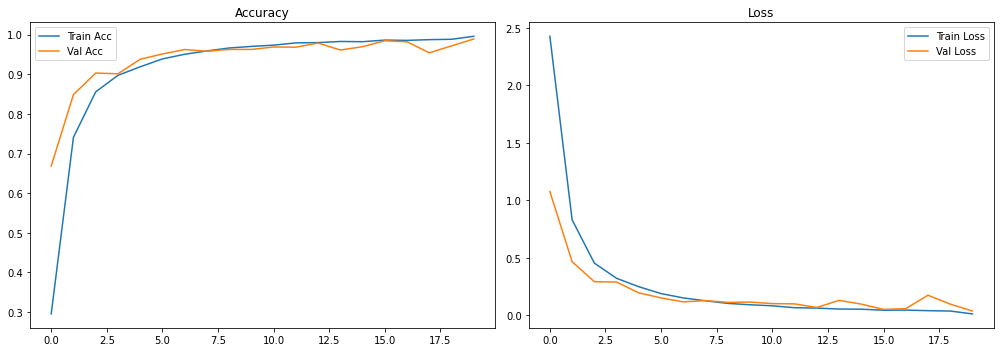

In [6]:
# Accuracy / Loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

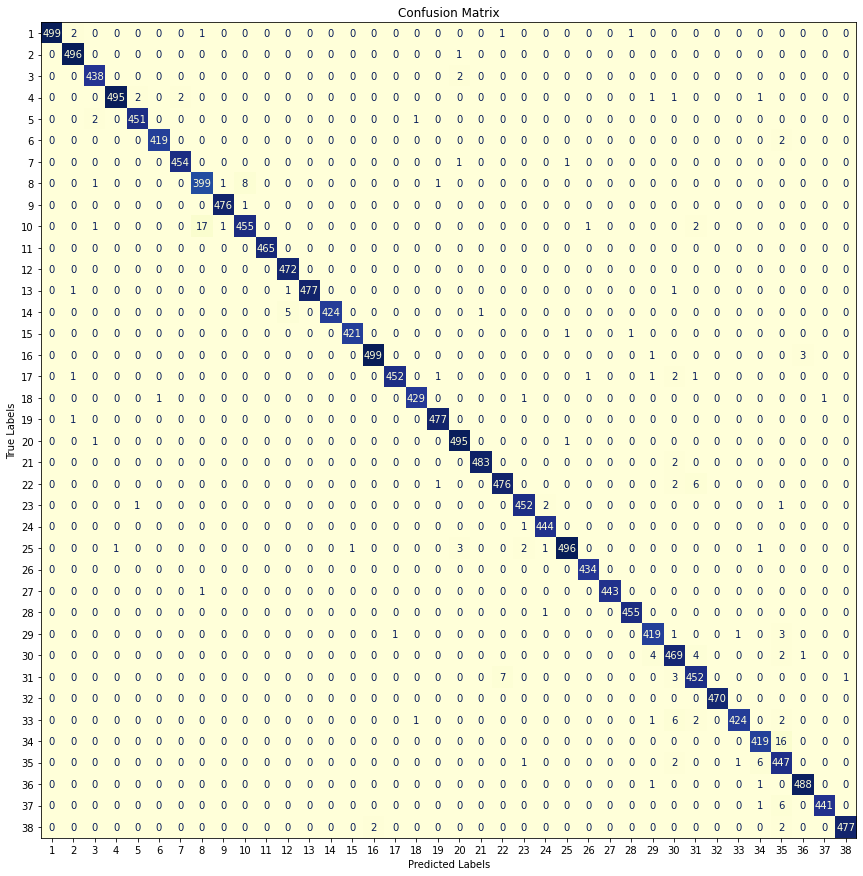

In [7]:
# Confusion Matrix
cm   = confusion_matrix(labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, 39)))
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(ax=ax, colorbar=False, cmap='YlGnBu')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## 5. Xuất Model ra File Object
Có 3 định dạng tuỳ nhu cầu triển khai:
- `.keras` — Keras native format (khuyến nghị cho TF ≥ 2.12)
- `.h5` — Legacy HDF5, tương thích rộng
- `TFLite (.tflite)` — Cho thiết bị nhúng / di động (ESP32, Android)

In [8]:
import os
save_dir = './'

# --- 1. Keras native format (recommended) ---
keras_path = os.path.join(save_dir, 'model_plant_disease.keras')
model.save(keras_path)
print(f'✅ Saved Keras model  : {keras_path}')

# --- 2. HDF5 legacy format ---
h5_path = os.path.join(save_dir, 'model_plant_disease.h5')
model.save(h5_path)
print(f'✅ Saved HDF5 model   : {h5_path}')

# --- 3. TFLite (for edge / IoT deployment) ---
converter    = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
tflite_path  = os.path.join(save_dir, 'model_plant_disease.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f'✅ Saved TFLite model : {tflite_path}')

✅ Saved Keras model  : ./model_plant_disease.keras
✅ Saved HDF5 model   : ./model_plant_disease.h5
✅ Saved TFLite model : ./model_plant_disease.tflite


## 6. Load lại Model & Inference nhanh

In [9]:
loaded_model = keras.models.load_model(keras_path)

sample_images, sample_labels = next(iter(test_gen))
sample_preds = tf.argmax(loaded_model.predict(sample_images[:5]), axis=1).numpy()
print('Ground truth :', sample_labels[:5].numpy())
print('Predicted    :', sample_preds)

Ground truth : [26 35 21  9 15]
Predicted    : [26 35 21  9 15]
